Importing Modules

In [1]:
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering
from kneed import KneeLocator
from sklearn.metrics import silhouette_score

Importing Data

In [2]:
df = pd.read_csv("../data/smartcart_customers.csv")
df["Income"] = df["Income"].fillna(df["Income"].mean())

Data Handling and Feature Engineering

In [3]:
#Age
df["Age"] = 2026-df["Year_Birth"]

#Customer tenure days
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)
ref_dt = df["Dt_Customer"].max()
df["Customer_Tenure_Days"] = (ref_dt-df["Dt_Customer"]).dt.days

In [4]:
#Spending
df["Total_Spending"] = df["MntWines"]+df["MntFruits"]+df["MntFishProducts"]+df["MntGoldProds"]+df["MntMeatProducts"]+df["MntSweetProducts"]

#Children
df["Total_Children"] = df["Kidhome"]+df["Teenhome"]

In [5]:
#Education
df["Education"].value_counts()
df["Education"] = df["Education"].map({"Basic":"Undergrad", "2n Cycle":"Undergrad", "Graduation":"Grad", "PhD":"Postgrad", "Master":"Postgrad"})

In [6]:
#Marital Status
df["Marital_Status"].value_counts()
df["Marital_Status"]= df["Marital_Status"].replace({"Together":"Married", "Divorced":"Single", "Widow":"Single", "YOLO":"Single", "Alone":"Single", "Absurd":"Single"})

In [7]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days', 'Total_Spending',
       'Total_Children'],
      dtype='object')

In [8]:
#Dropping unnecessary columns
cols = ["Year_Birth", "Dt_Customer", "ID", "Kidhome", "Teenhome", "MntWines", "MntFishProducts", "MntSweetProducts","MntMeatProducts", "MntFruits", "MntGoldProds"]
df_clean = df.drop(cols, axis=1)

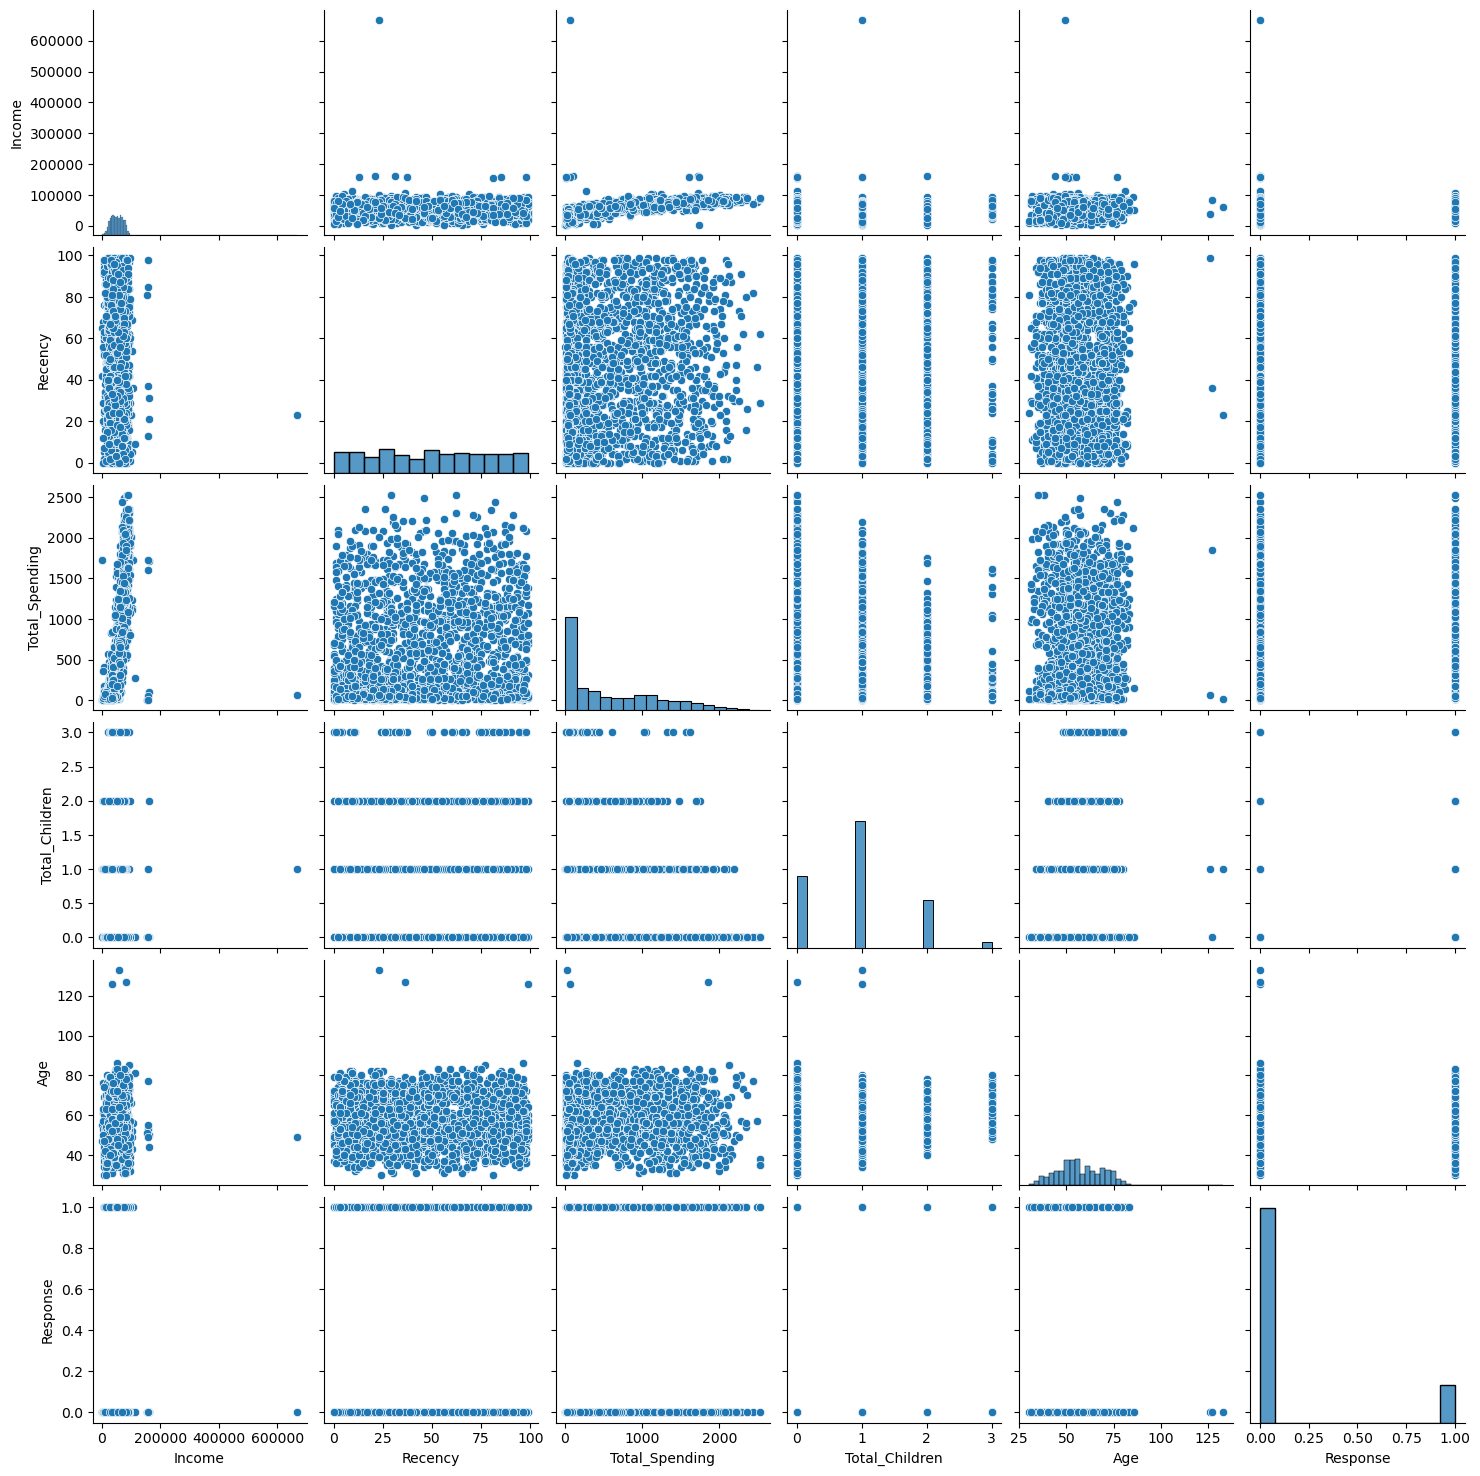

In [9]:
cols = ["Income", "Recency", "Total_Spending", "Total_Children", "Age", "Response"]
sns.pairplot(df_clean[cols])

Removing Outliers

In [10]:
print(f"original length = {len(df_clean)}")
df_clean = df_clean[(df_clean["Age"]<90)]
df_clean = df_clean[(df_clean["Income"]<600000)]
print(f"length after removing outliers = {len(df_clean)}")

original length = 2240
length after removing outliers = 2236


Heatmap

In [11]:
corr = df_clean.corr(numeric_only=True)

<Axes: >

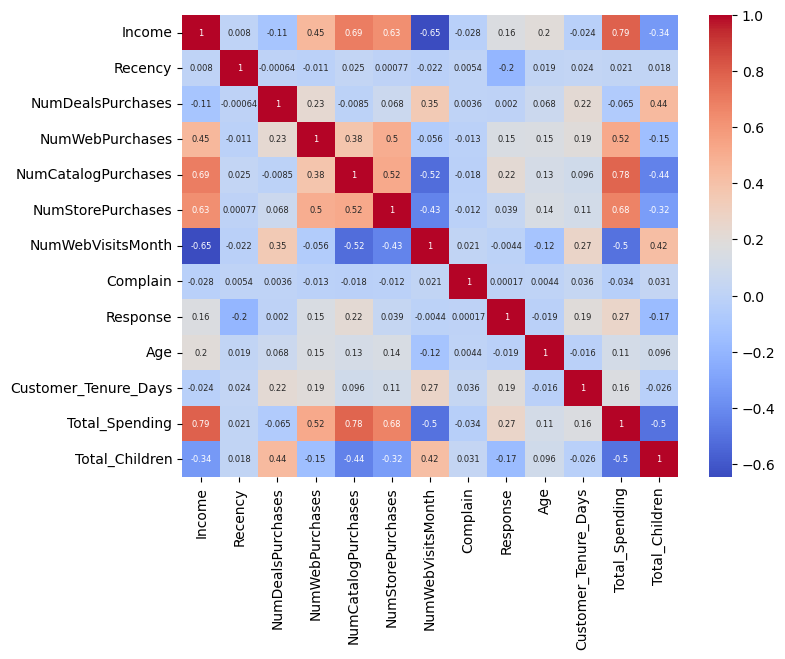

In [12]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap="coolwarm"
)

Encoding

In [13]:
ohe = OneHotEncoder()
cat_cols = ["Education", "Marital_Status"]
enc_cols = ohe.fit_transform(df_clean[cat_cols])

In [14]:
enc_df = pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=df_clean.index)

In [15]:
enc_df = enc_df.convert_dtypes("int64")

In [16]:
df_encoded = pd.concat([df_clean.drop(columns=cat_cols), enc_df],axis=1)

In [17]:
df_encoded

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Grad,Education_Postgrad,Education_Undergrad,Marital_Status_Married,Marital_Status_Single
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1,0,0,0,1
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1,0,0,0,1
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1,0,0,1,0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1,0,0,1,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,61223.0,46,2,9,3,4,5,0,0,59,381,1341,1,1,0,0,1,0
2236,64014.0,56,7,8,2,5,7,0,0,80,19,444,3,0,1,0,1,0
2237,56981.0,91,1,2,3,13,6,0,0,45,155,1241,0,1,0,0,0,1
2238,69245.0,8,2,6,5,10,3,0,0,70,156,843,1,0,1,0,1,0


Scaling

In [18]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

Visualisation

<Axes: >

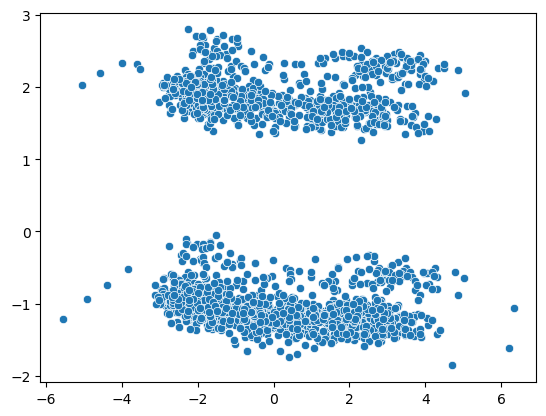

In [19]:
#2D

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1])

In [20]:
pca.explained_variance_ratio_

array([0.23162286, 0.11385437])

Text(0.5, 0.92, '3D scatterplot')

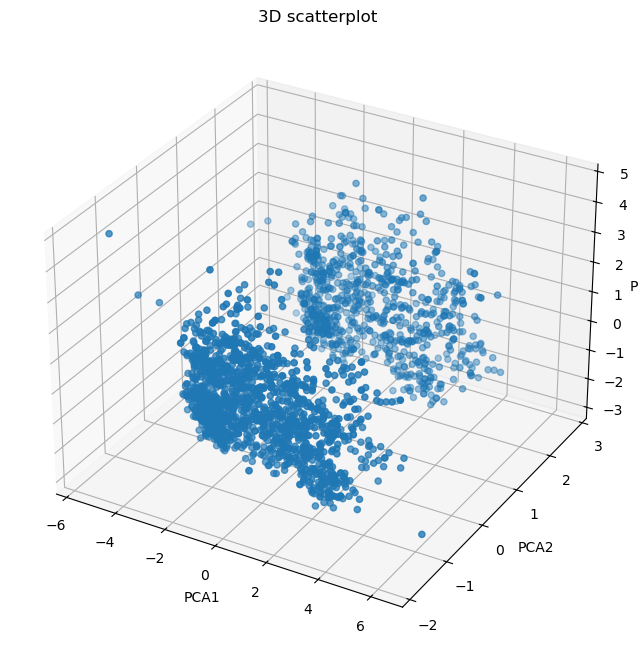

In [21]:
#3D
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2])
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D scatterplot")

In [22]:
pca.explained_variance_ratio_

array([0.23162286, 0.11385437, 0.1040582 ])

Optimal no. of Clusters

c:\Users\muska\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\muska\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\muska\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\muska\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

optimal k = 4


c:\Users\muska\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\muska\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\muska\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\muska\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

<Axes: >

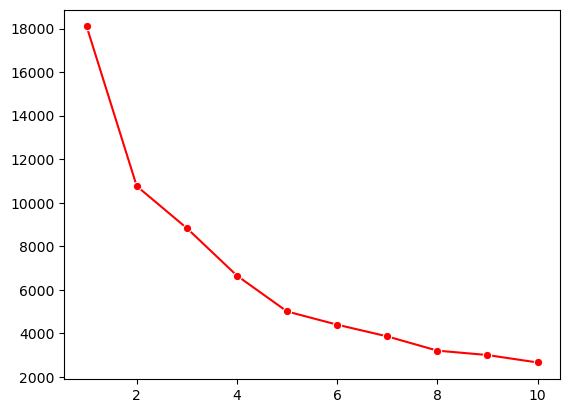

In [23]:
#Elbow Method
wcss = []
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)


knee = KneeLocator(range(1,11), wcss, curve='convex', direction='decreasing')
print(f"optimal k = {knee.knee}")
sns.lineplot(x=range(1,11), y=wcss, c="red", marker='o')

c:\Users\muska\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\muska\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\muska\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\muska\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

<Axes: >

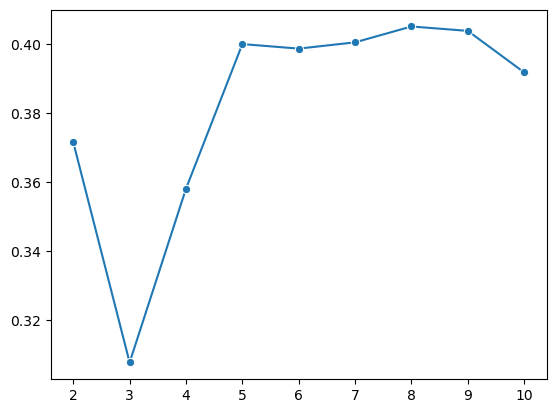

In [24]:
#silhouette score
score = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    label = kmeans.fit_predict(X_pca)
    score.append(silhouette_score(X_pca, label))#silhouette score
score = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    label = kmeans.fit_predict(X_pca)
    score.append(silhouette_score(X_pca, label))
    
sns.lineplot(x=range(2,11), y=score, marker='o')

Text(0, 0.5, 'wcss')

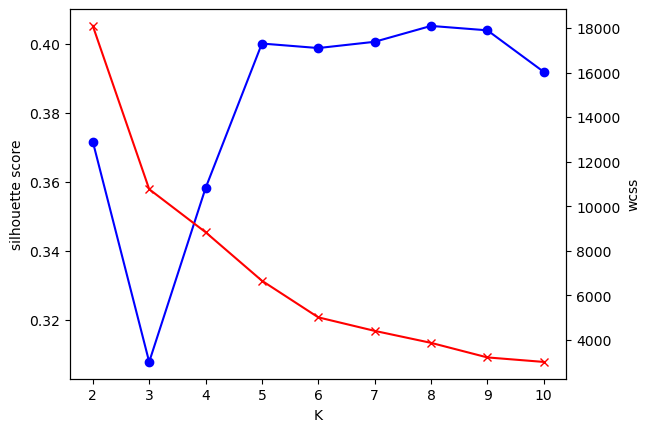

In [25]:
fig, ax1 = plt.subplots()
ax1.plot(range(2,11), score, c="blue", marker='o')
ax1.set_xlabel("K")
ax1.set_ylabel("silhouette score")
ax2 = ax1.twinx()
ax2.plot(range(2,11), wcss[:len(range(2,11))], color="red", marker='x')
ax2.set_ylabel("wcss")

KMeans Algorithm

c:\Users\muska\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


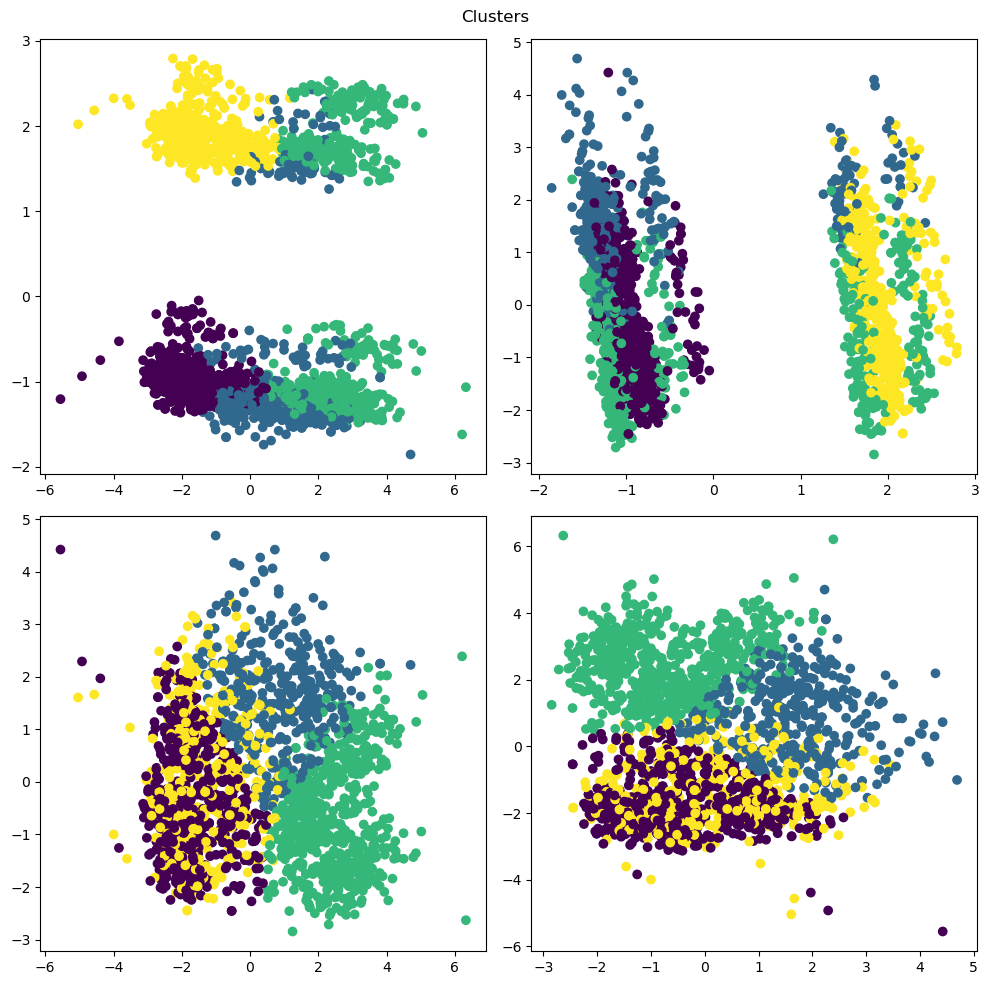

In [26]:

kmean = KMeans(n_clusters=4, random_state=42)
labels = kmean.fit_predict(X_pca)
fig, ax = plt.subplots(2,2)
ax[0][0].scatter(x=X_pca[:,0], y=X_pca[:,1], c=labels)
ax[1][0].scatter(x=X_pca[:,0], y=X_pca[:,2], c=labels)
ax[0][1].scatter(x=X_pca[:,1], y=X_pca[:,2], c=labels)
ax[1][1].scatter(x=X_pca[:,2], y=X_pca[:,0], c=labels)
fig.set_figheight(10)
fig.set_figwidth(10)
fig.suptitle("Clusters")
fig.tight_layout()

Text(0.5, 0.92, '3D scatterplot - Kmeans')

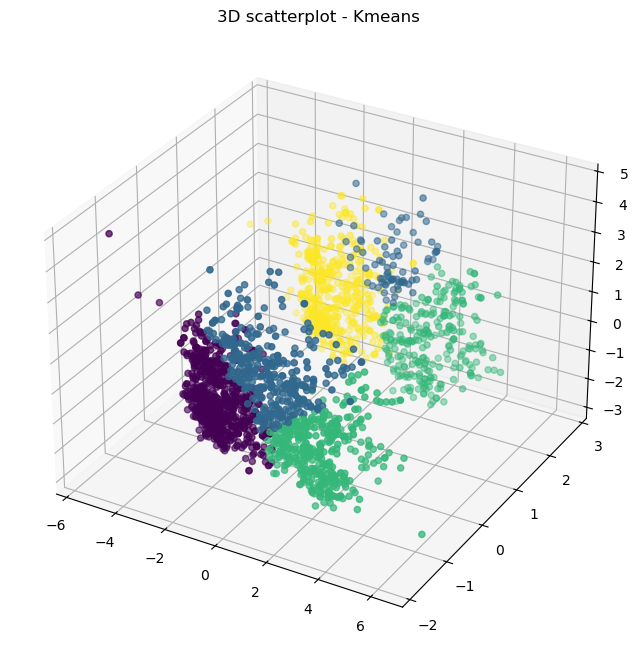

In [27]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=labels)
ax.set_title("3D scatterplot - Kmeans")

Agglomerative Clustering Algorithm

Text(0.5, 0.92, '3D scatterplot - Agglomerative Clustering')

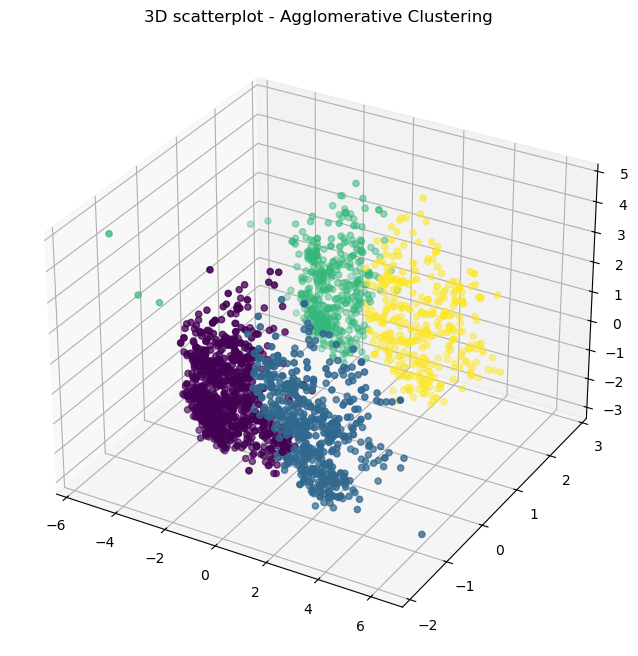

In [28]:
agg = AgglomerativeClustering(n_clusters=4)
labels = agg.fit_predict(X_pca)
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=labels)
ax.set_title("3D scatterplot - Agglomerative Clustering")

In [29]:
df_encoded["Cluster"] = labels
df_encoded

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Grad,Education_Postgrad,Education_Undergrad,Marital_Status_Married,Marital_Status_Single,Cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1,0,0,0,1,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1,0,0,0,1,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1,0,0,1,0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1,0,0,1,0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,61223.0,46,2,9,3,4,5,0,0,59,381,1341,1,1,0,0,1,0,0
2236,64014.0,56,7,8,2,5,7,0,0,80,19,444,3,0,1,0,1,0,0
2237,56981.0,91,1,2,3,13,6,0,0,45,155,1241,0,1,0,0,0,1,3
2238,69245.0,8,2,6,5,10,3,0,0,70,156,843,1,0,1,0,1,0,1


<Axes: xlabel='Cluster', ylabel='count'>

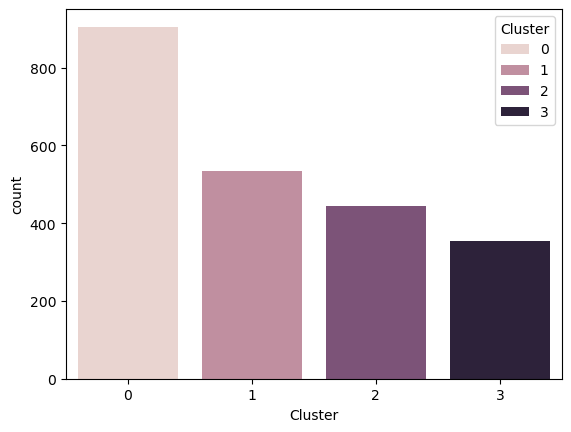

In [30]:
sns.countplot(x=df_encoded["Cluster"], hue=df_encoded["Cluster"])

<Axes: xlabel='Income', ylabel='Total_Spending'>

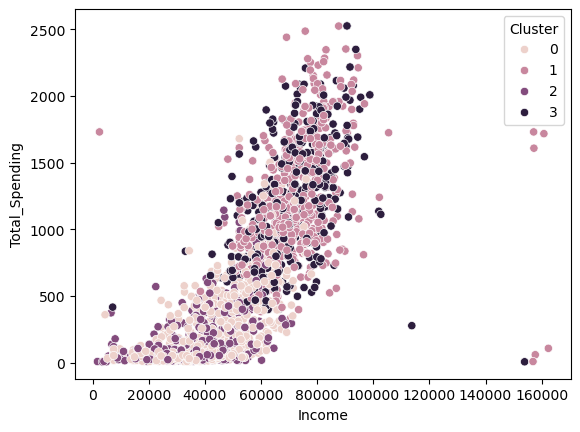

In [31]:
#Total Spending and Income
sns.scatterplot(data=df_encoded, x="Income", y="Total_Spending", hue=df_encoded["Cluster"])

Cluster Summary

In [32]:
cluster_summary = df_encoded.groupby("Cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
Cluster                                                                
0        39690.146424  48.914917           2.594475         3.153591   
1        72814.930722  49.202247           1.958801         5.687266   
2        36973.792251  48.319820           2.594595         2.713964   
3        70730.038963  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
Cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Customer_Tenure_Days  Total_Spending  \
Cluster         